[Previous: Module 2: Quantum Logic Gates](02_Quantum_Logic_Gates.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 4: Measurement & Interference](04_Measurement_and_Interference.ipynb)

# Module 3: Multiple Qubits & Entanglement

**Learning objectives.** After this module you can:

* combine single-qubit states into a multi-qubit state with the tensor product, and read Qiskit's bit ordering correctly;
* explain the CNOT gate as a matrix and as a truth table;
* build the Bell state and show, with numbers, that it is *entangled* and not merely *random*;
* construct all four Bell states and a three-qubit GHZ state.

**Prerequisites.** [Module 2](02_Quantum_Logic_Gates.ipynb): gates as matrices, Hadamard.

## 1. Multi-qubit maths: tensor products

Two qubits are not two separate vectors; they are **one** vector in a four-dimensional space. We combine single-qubit states with the
**tensor product** $\otimes$. If qubit 1 is $|a\rangle$ and qubit 0 is $|b\rangle$, the joint state is $|a\rangle \otimes |b\rangle = |ab\rangle$:

$$|0\rangle \otimes |0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix}
= \begin{pmatrix} 1\cdot 1 \\ 1\cdot 0 \\ 0\cdot 1 \\ 0\cdot 0 \end{pmatrix} = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} = |00\rangle.$$

The four entries are the **amplitudes** of $|00\rangle, |01\rangle, |10\rangle, |11\rangle$ (in that order). Squaring them gives the probabilities.
A general two-qubit state has four amplitudes; $n$ qubits have $2^n$. That exponential growth is where quantum computers get their room to work.

> **Qiskit ordering.** Qiskit is *little-endian*: the **rightmost** character of a label is **qubit 0**.
> `'10'` means qubit 1 is $1$ and qubit 0 is $0$. Textbooks often use the opposite convention. When a result looks "backwards", this is why.

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, partial_trace
from qiskit.visualization import array_to_latex, plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# Build |10> two ways: from a label, and from a tensor product (^ is Qiskit's tensor operator).
from_label  = Statevector.from_label('10')
from_tensor = Statevector.from_label('1') ^ Statevector.from_label('0')   # qubit 1 ⊗ qubit 0

print("Same state?", from_label.equiv(from_tensor))
display(array_to_latex(from_label.data, prefix="|10\\rangle = "))
print("Amplitude index 2 (binary 10) is 1; everything else is 0.")

Same state? True


<IPython.core.display.Latex object>

Amplitude index 2 (binary 10) is 1; everything else is 0.


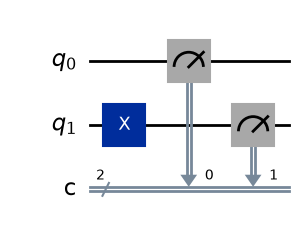

Result: {'10': 100}   <- qubit 1 is the LEFT digit, qubit 0 is the RIGHT digit


In [2]:
# The ordering rule, seen through a circuit: flip qubit 1 only.
qc = QuantumCircuit(2, 2)
qc.x(1)
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))

counts = simulator.run(qc, shots=100).result().get_counts()
print("Result:", counts, "  <- qubit 1 is the LEFT digit, qubit 0 is the RIGHT digit")

## 2. The CNOT gate (controlled-NOT)

CNOT acts on two qubits, a **control** and a **target**:

* if the control is $|0\rangle$, nothing happens;
* if the control is $|1\rangle$, apply X to the target.

Its matrix (in Qiskit's ordering, control = qubit 0, target = qubit 1) and truth table:

$$\text{CNOT} = \begin{pmatrix} 1&0&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \\ 0&1&0&0 \end{pmatrix}
\qquad
\begin{array}{c|c}
\text{in } |q_1 q_0\rangle & \text{out} \\ \hline
|00\rangle & |00\rangle \\
|01\rangle & |11\rangle \\
|10\rangle & |10\rangle \\
|11\rangle & |01\rangle
\end{array}$$

On its own CNOT is a classical gate (an XOR into the target). It becomes quantum when its control is in superposition.

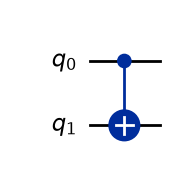

<IPython.core.display.Latex object>

Truth table (labels are |q1 q0>):
  |00>  ->  |00>
  |01>  ->  |11>
  |10>  ->  |10>
  |11>  ->  |01>


In [3]:
cnot = QuantumCircuit(2)
cnot.cx(0, 1)          # control = qubit 0, target = qubit 1
display(cnot.draw('mpl'))
display(array_to_latex(Operator(cnot).data, prefix="\\text{CNOT} = "))

print("Truth table (labels are |q1 q0>):")
for label in ['00', '01', '10', '11']:
    out = Statevector.from_label(label).evolve(cnot)
    out_label = max(out.probabilities_dict(), key=out.probabilities_dict().get)
    print(f"  |{label}>  ->  |{out_label}>")

## 3. Random is not the same as entangled

Put a Hadamard on *both* qubits and you get all four outcomes with equal probability. Put a Hadamard on one qubit and a CNOT after it and you get
only two outcomes. Which circuit is "more quantum"? The second one, and the reason is not the number of outcomes.

**Product state (H ⊗ H):**
$$|+\rangle \otimes |+\rangle = \tfrac{1}{2}\big(|00\rangle + |01\rangle + |10\rangle + |11\rangle\big).$$
Each qubit is in its own state $|+\rangle$; the joint state is just the two written side by side.

**Bell state (H then CNOT):**
1. H puts qubit 0 in $\tfrac{1}{\sqrt2}(|0\rangle + |1\rangle)$.
2. CNOT flips qubit 1 *only in the branch where qubit 0 is 1*:
$$|\Phi^+\rangle = \tfrac{1}{\sqrt2}\big(|00\rangle + |11\rangle\big).$$

This state **cannot** be written as $|a\rangle \otimes |b\rangle$ for any single-qubit states $a$ and $b$. Try it: you would need $|01\rangle$ and $|10\rangle$ to have zero amplitude while $|00\rangle$ and $|11\rangle$ do not, and no product of two vectors does that.
That impossibility is the definition of **entanglement**.

Product state  H⊗H |00>:


<IPython.core.display.Latex object>

Bell state  CNOT (H⊗I) |00>:


<IPython.core.display.Latex object>

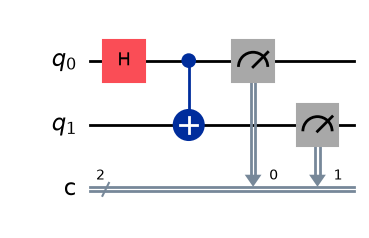

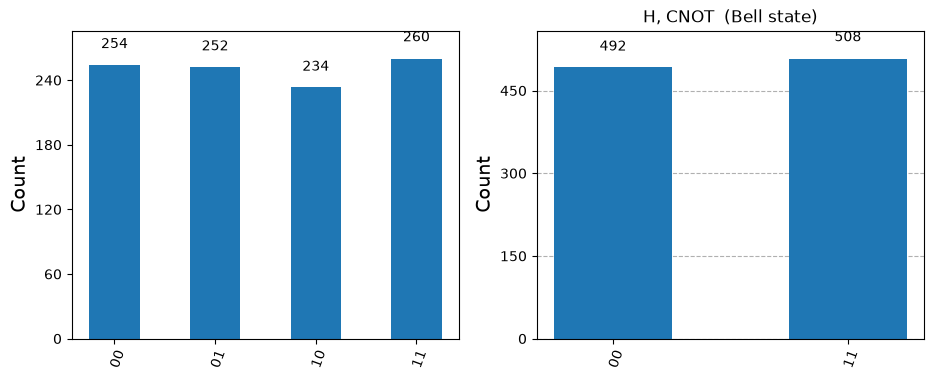

In [4]:
# Circuit A: two independent superpositions
product = QuantumCircuit(2, 2)
product.h([0, 1])

# Circuit B: the Bell state
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)

print("Product state  H⊗H |00>:")
display(Statevector(product).draw('latex'))
print("Bell state  CNOT (H⊗I) |00>:")
display(Statevector(bell).draw('latex'))

product.measure([0, 1], [0, 1])
bell.measure([0, 1], [0, 1])
display(bell.draw('mpl'))

counts_product = simulator.run(product, shots=1000).result().get_counts()
counts_bell    = simulator.run(bell, shots=1000).result().get_counts()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_histogram(counts_product, ax=ax[0], title="H ⊗ H  (product state)")
plot_histogram(counts_bell,    ax=ax[1], title="H, CNOT  (Bell state)")
plt.show()

In [5]:
# Correlation check: how often do the two qubits agree?
def agreement(counts):
    total = sum(counts.values())
    same = sum(n for bits, n in counts.items() if bits[0] == bits[1])
    return same / total

print(f"Product state: qubits agree {agreement(counts_product):.1%} of the time  (independent coins)")
print(f"Bell state:    qubits agree {agreement(counts_bell):.1%} of the time  (perfectly correlated)")

Product state: qubits agree 51.4% of the time  (independent coins)
Bell state:    qubits agree 100.0% of the time  (perfectly correlated)


> **What to notice.** Look at either qubit *on its own* in the Bell state: it is 50/50, a fair coin. Look at the pair: they always match.
> The information is not in either qubit; it is in the *relationship*. That is entanglement, and it survives any distance between the qubits.

## 4. A rigorous entanglement test: look at one qubit alone

Ask: "if I ignore qubit 1 completely, what state is qubit 0 in?" The mathematical operation is the **partial trace**, and the answer is a
*density matrix* $\rho$ rather than a state vector. Its **purity** $\mathrm{Tr}(\rho^2)$ tells you how much you know:

* purity $= 1$: qubit 0 has a definite state of its own. The pair is a **product state**.
* purity $= 0.5$ (the minimum for one qubit): qubit 0 alone is *maximally mixed*, pure ignorance. The pair is **maximally entangled**.

This is how entanglement is quantified in practice, and it is one line of Qiskit.

In [6]:
for name, qc in [("Product H⊗H", product), ("Bell state", bell)]:
    state = Statevector(qc.remove_final_measurements(inplace=False))
    rho_q0 = partial_trace(state, [1])              # trace OUT qubit 1, keep qubit 0
    print(f"{name:<14} reduced state of qubit 0, purity = {rho_q0.purity().real:.2f}")
    display(array_to_latex(rho_q0.data, prefix="\\rho_{q_0} = "))

Product H⊗H    reduced state of qubit 0, purity = 1.00


<IPython.core.display.Latex object>

Bell state     reduced state of qubit 0, purity = 0.50


<IPython.core.display.Latex object>

Product state: each qubit is a clean |+> arrow


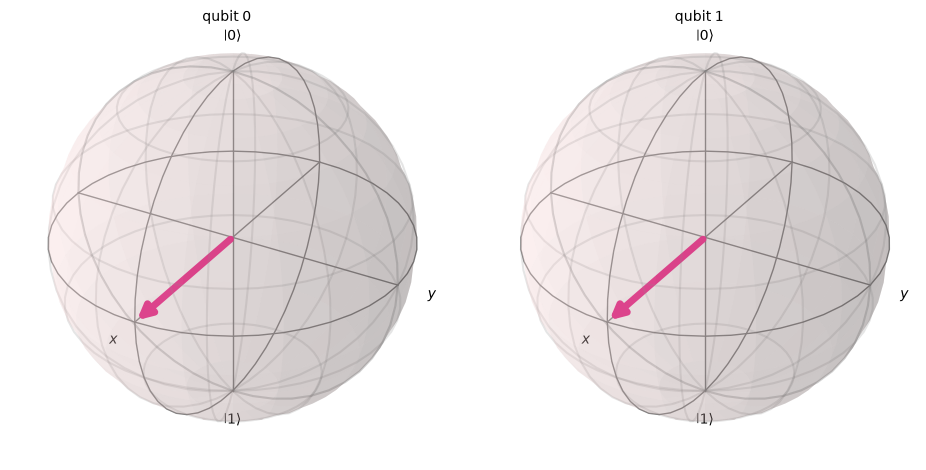

Bell state: each arrow has length zero, the qubit alone is maximally mixed


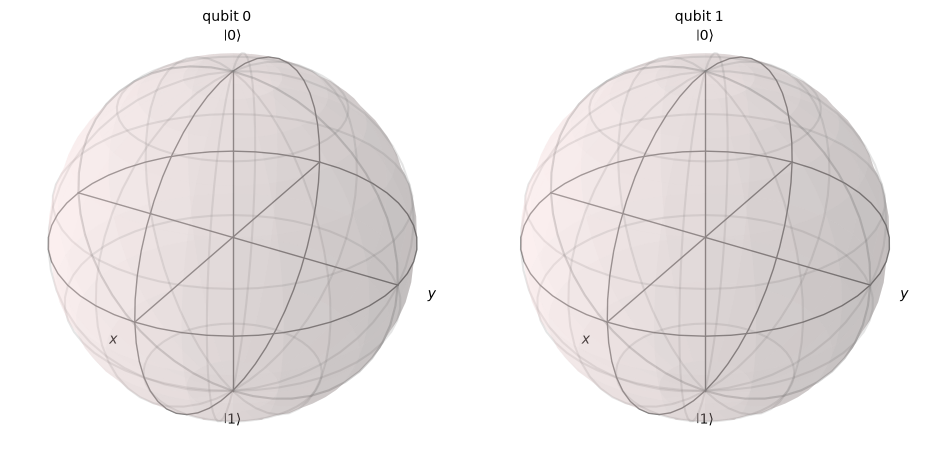

In [7]:
# The Bloch sphere shows the same thing: an entangled qubit has NO arrow of its own.
print("Product state: each qubit is a clean |+> arrow")
display(plot_bloch_multivector(Statevector(product.remove_final_measurements(inplace=False))))
print("Bell state: each arrow has length zero, the qubit alone is maximally mixed")
display(plot_bloch_multivector(Statevector(bell.remove_final_measurements(inplace=False))))

## 5. The four Bell states and the GHZ state

There are four maximally entangled two-qubit states. They differ only in a bit flip and a sign, and they are the alphabet of teleportation (Module 5):

| Name | State | Circuit before H, CNOT |
|------|-------|-------------------------|
| $\Phi^+$ | $\tfrac{1}{\sqrt2}(\lvert 00\rangle + \lvert 11\rangle)$ | nothing |
| $\Phi^-$ | $\tfrac{1}{\sqrt2}(\lvert 00\rangle - \lvert 11\rangle)$ | X on qubit 0 |
| $\Psi^+$ | $\tfrac{1}{\sqrt2}(\lvert 01\rangle + \lvert 10\rangle)$ | X on qubit 1 |
| $\Psi^-$ | $\tfrac{1}{\sqrt2}(\lvert 01\rangle - \lvert 10\rangle)$ | X on both |

Entanglement is not limited to pairs. Chain two CNOTs after one Hadamard and you get the three-qubit **GHZ state**
$\tfrac{1}{\sqrt2}(|000\rangle + |111\rangle)$: three coins that always land the same way.

In [8]:
def bell_state(x_on_q0=False, x_on_q1=False):
    qc = QuantumCircuit(2)
    if x_on_q0: qc.x(0)
    if x_on_q1: qc.x(1)
    qc.h(0)
    qc.cx(0, 1)
    return qc

for name, flags in [("Φ+", (False, False)), ("Φ-", (True, False)), ("Ψ+", (False, True)), ("Ψ-", (True, True))]:
    print(f"{name}:")
    display(Statevector(bell_state(*flags)).draw('latex'))

Φ+:


<IPython.core.display.Latex object>

Φ-:


<IPython.core.display.Latex object>

Ψ+:


<IPython.core.display.Latex object>

Ψ-:


<IPython.core.display.Latex object>

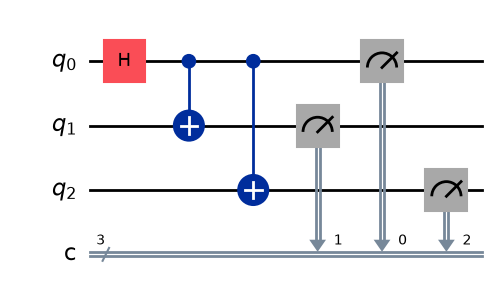

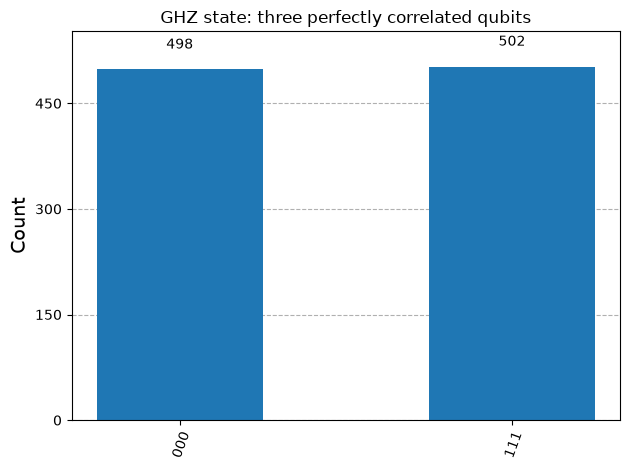

In [9]:
ghz = QuantumCircuit(3, 3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)
ghz.measure([0, 1, 2], [0, 1, 2])
display(ghz.draw('mpl'))

counts = simulator.run(ghz, shots=1000).result().get_counts()
plot_histogram(counts, title="GHZ state: three perfectly correlated qubits")

## Try it yourself

**Exercise 1.** Build $\Psi^-$ and confirm with the simulator that only `01` and `10` ever appear.

**Exercise 2.** Make a 4-qubit GHZ state. How many CNOTs do you need? Show the histogram.

**Exercise 3.** In the Bell circuit, swap the order: apply CNOT *first*, then H on qubit 0. Is the result entangled? Use the purity test.

**Exercise 4 (challenge).** Apply H to *both* qubits after creating $|\Phi^+\rangle$. Predict the state, then check with `Statevector`.
(Hint: $|\Phi^+\rangle$ looks the same in the X basis.)

<details><summary>Solutions</summary>

```python
# Exercise 1
qc = bell_state(True, True); qc.measure_all()
print(simulator.run(qc, shots=1000).result().get_counts())     # only '01' and '10'

# Exercise 2: one H and three CNOTs
qc = QuantumCircuit(4); qc.h(0); qc.cx(0, 1); qc.cx(0, 2); qc.cx(0, 3); qc.measure_all()
plot_histogram(simulator.run(qc, shots=1000).result().get_counts())

# Exercise 3: CNOT on |00> does nothing, so this is just H on qubit 0: a product state, purity 1
qc = QuantumCircuit(2); qc.cx(0, 1); qc.h(0)
print(partial_trace(Statevector(qc), [1]).purity().real)       # 1.0

# Exercise 4: (H⊗H)|Φ+> = |Φ+>. The Bell state is symmetric between the Z and X bases.
qc = bell_state(); qc.h([0, 1])
display(Statevector(qc).draw('latex'))
```

</details>

## Key takeaways

* $n$ qubits are one vector with $2^n$ amplitudes, built from single qubits by the tensor product. Qiskit writes qubit 0 on the right.
* CNOT flips the target when the control is 1; with a superposed control it entangles.
* Entangled means "cannot be written as a product". The test: trace out one qubit and check the purity of the other.
* The four Bell states are the maximally entangled pairs; GHZ extends the idea to more qubits.

**Next:** why phases matter and how interference works. [Module 4](04_Measurement_and_Interference.ipynb).

[Previous: Module 2: Quantum Logic Gates](02_Quantum_Logic_Gates.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 4: Measurement & Interference](04_Measurement_and_Interference.ipynb)